In [1]:
from pathlib import Path
import csv
import datetime
import os
import sys
from dataclasses import dataclass
from typing import List, Tuple

notebook_dir = Path(os.getcwd())
project_root_dir = notebook_dir.parent
if str(project_root_dir) not in sys.path:
    sys.path.insert(0, str(project_root_dir))

import seaborn as sns
import matplotlib.pyplot as plt
import pyrallis
import pandas as pd
import numpy as np

from config import Config, TrainConfig
import logs

In [2]:
import importlib
importlib.reload(logs)

<module 'logs' from '/mnt/SharedOne/bpanthi/model_search/logs.py'>

In [6]:
study_dir = project_root_dir.joinpath("logs/hgf-20p")
trials_all = logs.read_study(study_dir)
len(trials_all)

59

In [22]:
trials = []
for t in trials_all:
    if int(t.name[:8]) <= 20250603:
        trials.append(t)

df_till_now = logs.create_df(trials)
len(trials)

37

In [21]:
df = df_till_now.query("loss == 'smoothl1' & init == 'ku'")
df

,name,loss,batch_size,init,init_param,activation,hidden_layers,dropout,optimizer,lr,weight_decay,train_time,epoch,train_loss,val_loss
100,20250530-202645-senm,smoothl1,1024,ku,[],relu,[74],[],adamw,0.10,0.01,76.166667,1,7.897280,0.978767
101,20250530-202645-senm,smoothl1,1024,ku,[],relu,[74],[],adamw,0.10,0.01,76.166667,2,9.269247,22.080744
102,20250530-202645-senm,smoothl1,1024,ku,[],relu,[74],[],adamw,0.10,0.01,76.166667,3,8.866115,4.395997
103,20250530-202645-senm,smoothl1,1024,ku,[],relu,[74],[],adamw,0.10,0.01,76.166667,4,9.966504,5.533357
104,20250530-202645-senm,smoothl1,1024,ku,[],relu,[74],[],adamw,0.10,0.01,76.166667,5,10.432220,1.109766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.01,0.01,76.000000,96,0.083281,0.133806
3496,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.01,0.01,76.000000,97,0.077159,0.085626
3497,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.01,0.01,76.000000,98,0.087666,0.088912
3498,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.01,0.01,76.000000,99,0.060668,0.086596


In [4]:
study_dir_32 = project_root_dir.joinpath("logs/hgf-20p-32")
trials_32 = logs.read_study(study_dir_32)
df_32 = logs.create_df(trials_32)
len(trials_32)

IndexError: list index out of range

[None]

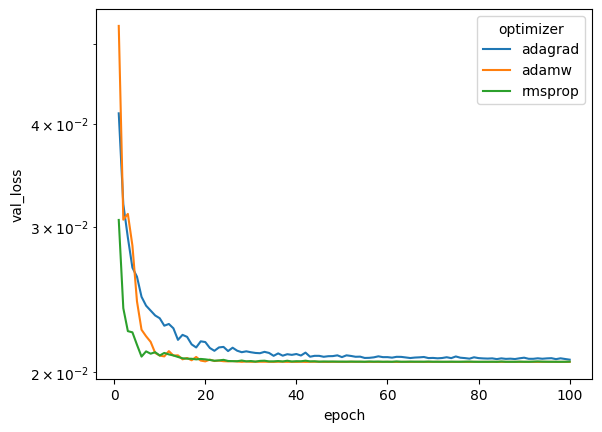

In [8]:
min_values = df.groupby(['optimizer', 'epoch'])['val_loss'].min().reset_index()
ax = sns.lineplot(min_values, x='epoch', y='val_loss', hue='optimizer')
ax.set(yscale='log')
plt.savefig("best_val_loss_01.svg")

[None]

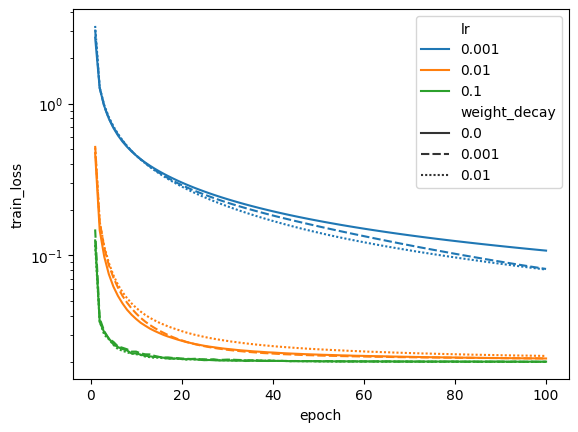

In [151]:
ax = sns.lineplot(df.query('optimizer=="adagrad"'), x='epoch', y='train_loss', hue='lr', style='weight_decay', palette='tab10')
ax.set(yscale='log')

[None]

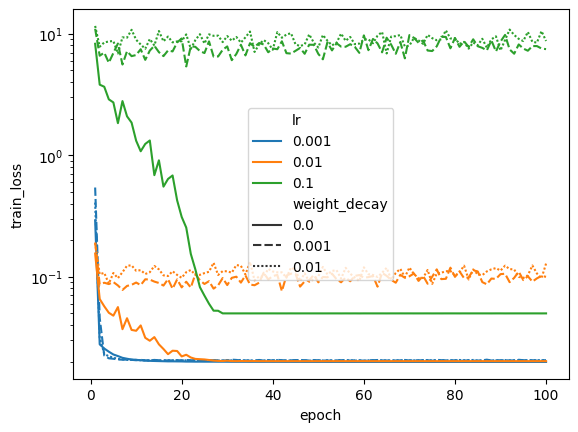

In [150]:
ax = sns.lineplot(df.query('optimizer=="rmsprop"'), x='epoch', y='train_loss', hue='lr', style='weight_decay', palette='tab10')
ax.set(yscale='log')

[None]

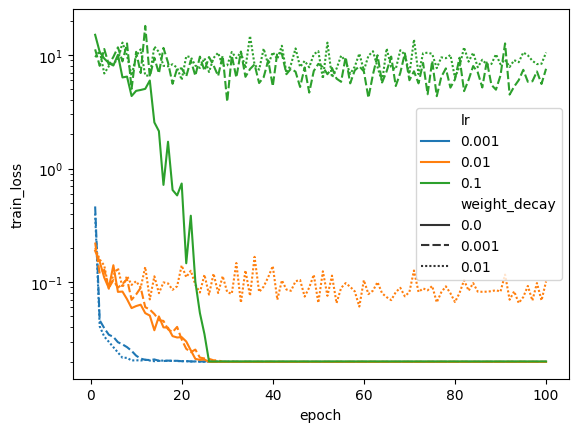

In [154]:
ax = sns.lineplot(df.query('optimizer=="adamw"'), x='epoch', y='train_loss', hue='lr', style='weight_decay', palette='tab10')
ax.set(yscale='log')

In [212]:
df.groupby(['optimizer'])['val_loss'].min(), df_32.groupby(['optimizer'])['val_loss'].min()

(optimizer
 adagrad    0.020704
 adamw      0.020574
 rmsprop    0.020582
 Name: val_loss, dtype: float64,
 optimizer
 adagrad    0.020680
 adamw      0.020575
 rmsprop    0.020611
 Name: val_loss, dtype: float64)

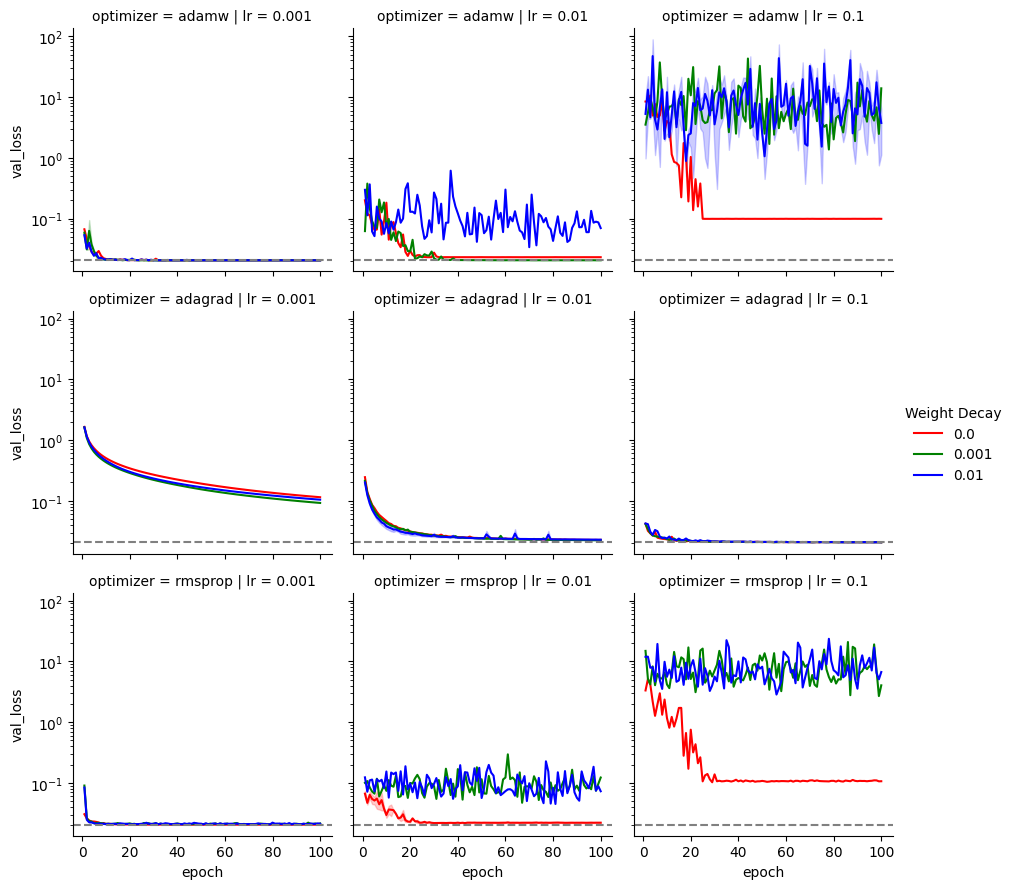

In [16]:
g = sns.FacetGrid(df, col="lr",  row="optimizer")
ax = g.map_dataframe(sns.lineplot, x="epoch", y="val_loss", hue='weight_decay', palette={0: "red", 0.001: "green", 0.01: "blue"})
g.refline(y=df['val_loss'].min(),)
ax.set(yscale='log')
g.add_legend(title="Weight Decay")
g.savefig("./val_loss_01.svg")

In [183]:
df['val_loss'].min(), df_32['val_loss'].min()

(np.float64(0.0205744262947564), np.float64(0.020574849301084882))

In [203]:
df['train_loss'].min(), df_32['train_loss'].min()

(np.float64(0.019860981492658164), np.float64(0.01986098925424217))